In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data.values / 255.0
y = mnist.target.astype(int).values.reshape(-1,1)

encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

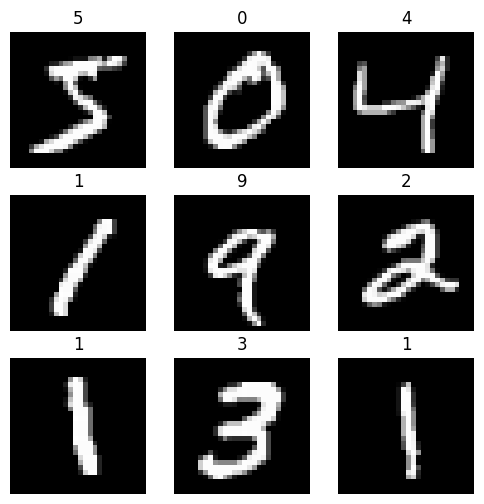

In [3]:
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i].reshape(28,28), cmap='gray')
    plt.title(np.argmax(y[i]))
    plt.axis('off')
plt.show()

In [4]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [5]:
def dropout(A, rate):
    mask = (np.random.rand(*A.shape) > rate).astype(float)
    return A * mask / (1 - rate), mask

In [6]:
def init_weights():
    W1 = np.random.randn(784,128) * np.sqrt(2/784)
    b1 = np.zeros((1,128))

    W2 = np.random.randn(128,64) * np.sqrt(2/128)
    b2 = np.zeros((1,64))

    W3 = np.random.randn(64,10) * np.sqrt(2/64)
    b3 = np.zeros((1,10))

    return W1,b1,W2,b2,W3,b3

In [7]:
def forward(X, W1, b1, W2, b2, W3, b3, activation="relu"):

    Z1 = X @ W1 + b1
    A1 = relu(Z1) if activation=="relu" else sigmoid(Z1)
    A1, D1 = dropout(A1, 0.2)

    Z2 = A1 @ W2 + b2
    A2 = relu(Z2) if activation=="relu" else sigmoid(Z2)
    A2, D2 = dropout(A2, 0.2)

    Z3 = A2 @ W3 + b3
    A3 = softmax(Z3)

    return Z1,A1,D1,Z2,A2,D2,Z3,A3

In [8]:
def loss(y, A3):
    return -np.mean(y * np.log(A3 + 1e-8))

In [9]:
def backward(X,y,Z1,A1,D1,Z2,A2,D2,A3,W2,W3,activation):

    m = X.shape[0]

    dZ3 = A3 - y
    dW3 = A2.T @ dZ3 / m
    db3 = np.sum(dZ3,axis=0,keepdims=True)/m

    dA2 = dZ3 @ W3.T
    dA2 *= D2

    if activation=="relu":
        dZ2 = dA2 * relu_derivative(Z2)
    else:
        dZ2 = dA2 * sigmoid_derivative(Z2)

    dW2 = A1.T @ dZ2 / m
    db2 = np.sum(dZ2,axis=0,keepdims=True)/m

    dA1 = dZ2 @ W2.T
    dA1 *= D1

    if activation=="relu":
        dZ1 = dA1 * relu_derivative(Z1)
    else:
        dZ1 = dA1 * sigmoid_derivative(Z1)

    dW1 = X.T @ dZ1 / m
    db1 = np.sum(dZ1,axis=0,keepdims=True)/m

    return dW1,db1,dW2,db2,dW3,db3

In [10]:
def batches(X,y,bs=64):
    for i in range(0,X.shape[0],bs):
        yield X[i:i+bs], y[i:i+bs]

In [11]:
def train(activation):

    W1,b1,W2,b2,W3,b3 = init_weights()

    lr = 0.01
    epochs = 10
    losses = []

    for e in range(epochs):
        for xb,yb in batches(X_train,y_train):

            Z1,A1,D1,Z2,A2,D2,Z3,A3 = forward(xb,W1,b1,W2,b2,W3,b3,activation)

            l = loss(yb,A3)

            dW1,db1,dW2,db2,dW3,db3 = backward(
                xb,yb,Z1,A1,D1,Z2,A2,D2,A3,W2,W3,activation
            )

            W1 -= lr*dW1
            b1 -= lr*db1
            W2 -= lr*dW2
            b2 -= lr*db2
            W3 -= lr*dW3
            b3 -= lr*db3

        losses.append(l)
        print(f"{activation} Epoch {e+1}: {l:.4f}")

    return W1,b1,W2,b2,W3,b3,losses

In [12]:
relu_model = train("relu")
sigmoid_model = train("sigmoid")

relu Epoch 1: 0.0706
relu Epoch 2: 0.0465
relu Epoch 3: 0.0587
relu Epoch 4: 0.0468
relu Epoch 5: 0.0356
relu Epoch 6: 0.0429
relu Epoch 7: 0.0419
relu Epoch 8: 0.0282
relu Epoch 9: 0.0323
relu Epoch 10: 0.0344
sigmoid Epoch 1: 0.2269
sigmoid Epoch 2: 0.2100
sigmoid Epoch 3: 0.2052
sigmoid Epoch 4: 0.1785
sigmoid Epoch 5: 0.1588
sigmoid Epoch 6: 0.1414
sigmoid Epoch 7: 0.1311
sigmoid Epoch 8: 0.1186
sigmoid Epoch 9: 0.1113
sigmoid Epoch 10: 0.0971


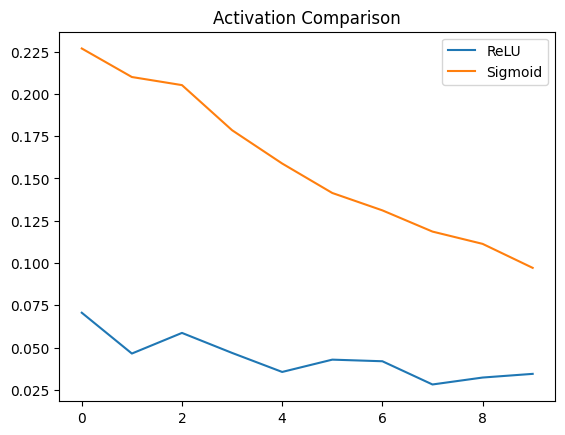

In [13]:
plt.plot(relu_model[6], label="ReLU")
plt.plot(sigmoid_model[6], label="Sigmoid")
plt.legend()
plt.title("Activation Comparison")
plt.show()

In [14]:
def test(model):

    W1,b1,W2,b2,W3,b3,_ = model

    _,_,_,_,_,_,_,A3 = forward(X_test,W1,b1,W2,b2,W3,b3)

    pred = np.argmax(A3,axis=1)
    true = np.argmax(y_test,axis=1)

    return pred,true

pred,true = test(relu_model)

print("Accuracy:", accuracy_score(true,pred))

Accuracy: 0.9114285714285715
